# QUEST na cvičení
- Dataset pre tento projekt je **Netflix 10+ Year Stock Data** stiahnutý z kaggle.com
- Názov datasetu je NFLX

# IMPORTY

In [100]:
# === IMPORTY ===
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
# Zobrazovanie grafov
%matplotlib inline


df = pd.read_csv("NFLX.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000
1,2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800
2,2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400
3,2002-05-29,1.164286,1.164286,1.085714,1.103571,1.103571,6757800
4,2002-05-30,1.107857,1.107857,1.071429,1.071429,1.071429,10154200


## 4.1  EDA and data preprocessing

### 4.1(A)	EDA a data preprocessing pre Vami vybrané charakteristiky z datasetu 


Základné informácie o datasete:

In [101]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4581 entries, 0 to 4580
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4581 non-null   object 
 1   Open       4581 non-null   float64
 2   High       4581 non-null   float64
 3   Low        4581 non-null   float64
 4   Close      4581 non-null   float64
 5   Adj Close  4581 non-null   float64
 6   Volume     4581 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 250.6+ KB


Všetky data su v type int alebo float.

Zistili sme,že dátum je v nesprávnom type preto ho pretypujeme na datetime a zoradíme dataset podľa dátumu

In [102]:
# Pretypovanie dátumu
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Zoradenie podľa dátumu
df = df.sort_values("Date").reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4581 entries, 0 to 4580
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4581 non-null   datetime64[ns]
 1   Open       4581 non-null   float64       
 2   High       4581 non-null   float64       
 3   Low        4581 non-null   float64       
 4   Close      4581 non-null   float64       
 5   Adj Close  4581 non-null   float64       
 6   Volume     4581 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 250.6 KB


Ďalej sme sa pozreli na chýbajúce údaje pomocou nasledujúceho kódu:

In [103]:
print("Počet chýbajúcich hodnôt v jednotlivých stĺpcoch:")
df.isna().sum()

Počet chýbajúcich hodnôt v jednotlivých stĺpcoch:


Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Po vípise sme zistili že žiadny stĺpec v datasete nemá chýbajúce údaje, čo je pozitívna informácia

In [104]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,4581,4581.000000,4581.000000,4581.000000,4581.000000,4581.000000,4.581000e+03
mean,2011-06-27 20:17:07.897838592,78.031471,79.285690,76.736079,78.072056,78.072056,1.760516e+07
min,2002-05-23 00:00:00,0.377857,0.410714,0.346429,0.372857,0.372857,2.856000e+05
25%,2006-12-07 00:00:00,3.778571,3.857143,3.685714,3.784286,3.784286,6.908900e+06
50%,2011-06-27 00:00:00,15.392858,15.671429,14.970000,15.324286,15.324286,1.155350e+07
75%,2016-01-14 00:00:00,97.830002,99.529999,96.760002,97.889999,97.889999,2.113440e+07
max,2020-08-03 00:00:00,567.979980,575.369995,520.960022,548.729980,548.729980,3.234140e+08
std,NaN,118.372084,120.276839,116.376768,118.435303,118.435303,1.971130e+07


Časové rozhranie je od roku 2002 až po rok 2020, čo znamená časové rozhranie okolo 18 rokov.

Podľa percentuálneho rozdelenia vidno, že dáta su priemerne rozdelené

Štandardná odchylka je približne 118 čo naznačuje vyokú volatlitu


Dataset neobsahuje záporné hodnoty ani žiadne nelogické hodnoty, čo znamená že dataset je konzistentný

Vývoj cien

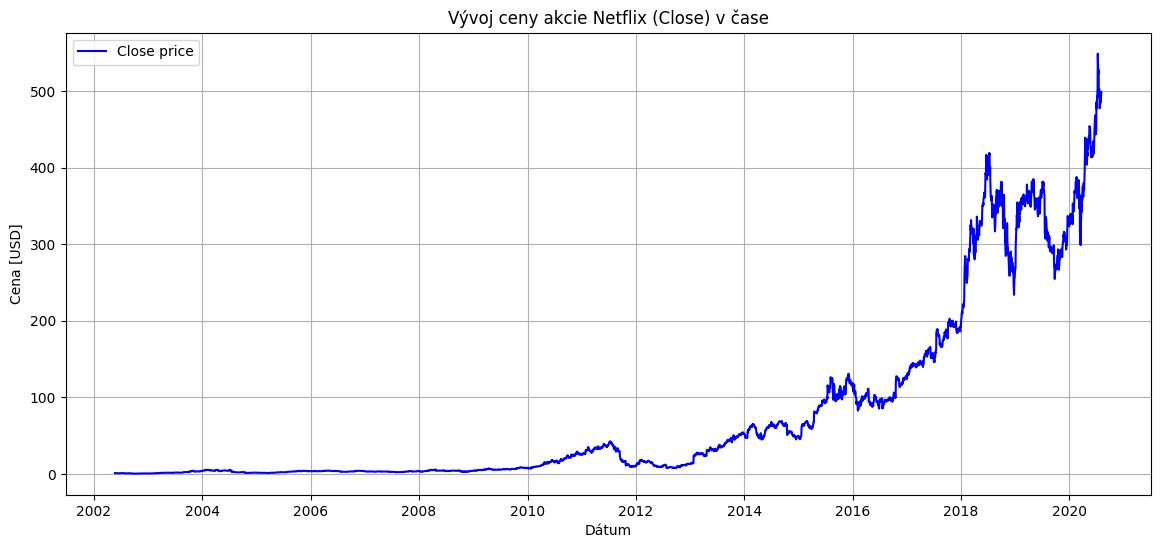

In [105]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Close"], label="Close price", color="blue")
plt.title("Vývoj ceny akcie Netflix (Close) v čase")
plt.xlabel("Dátum")
plt.ylabel("Cena [USD]")
plt.grid(True)
plt.legend()
plt.show()



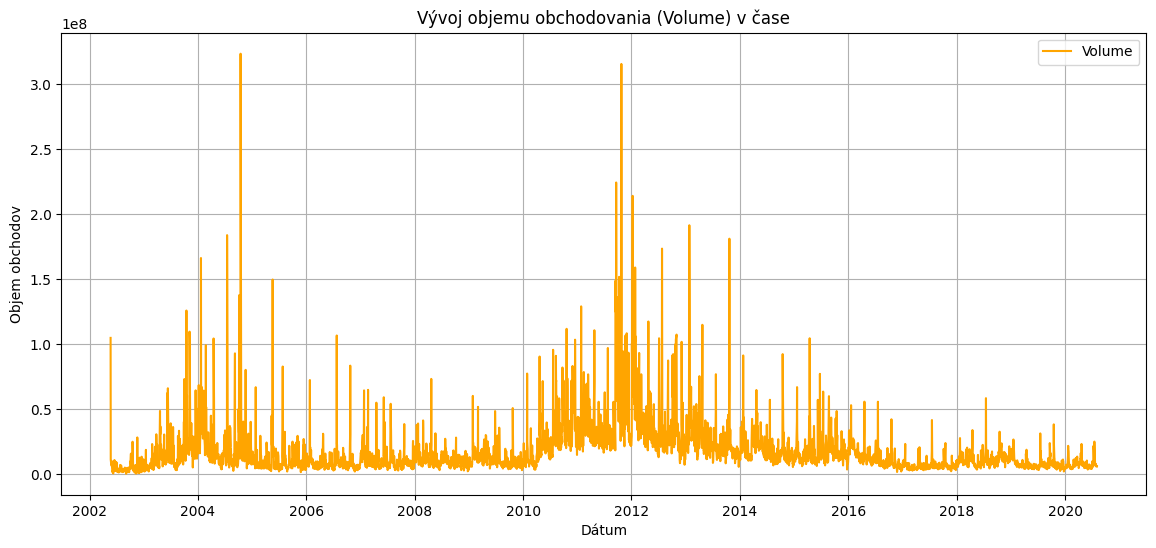

In [106]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Volume"], label="Volume", color="orange")
plt.title("Vývoj objemu obchodovania (Volume) v čase")
plt.xlabel("Dátum")
plt.ylabel("Objem obchodov")
plt.grid(True)
plt.legend()
plt.show()


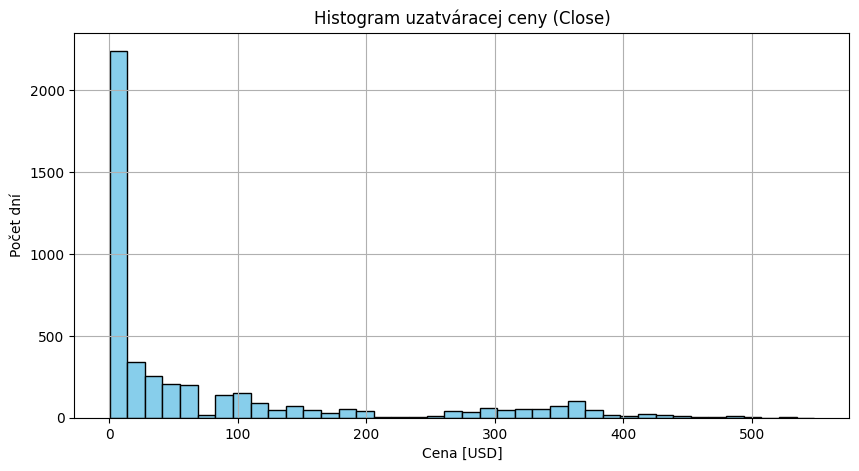

In [107]:
plt.figure(figsize=(10,5))
plt.hist(df["Close"], bins=40, color="skyblue", edgecolor="black")
plt.title("Histogram uzatváracej ceny (Close)")
plt.xlabel("Cena [USD]")
plt.ylabel("Počet dní")
plt.grid(True)
plt.show()


Netflix mal v histórií viacero splitov

To znamená:

- staré ceny boli spätne prepočítané na extrémne nízke hodnoty (1–5 USD)

- nové ceny pred splitmi boli prepočítané smerom nadol

- historické rozdelenie tak nie je prirodzené, ale technicky upravené

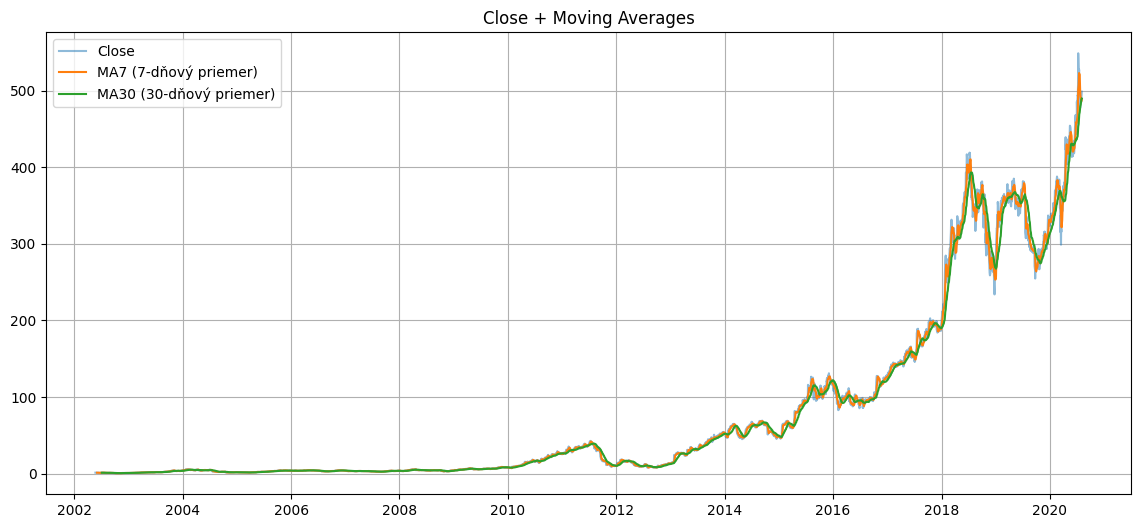

In [108]:
df["MA7"] = df["Close"].rolling(window=7).mean()
df["MA30"] = df["Close"].rolling(window=30).mean()

plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Close"], label="Close", alpha=0.5)
plt.plot(df["Date"], df["MA7"], label="MA7 (7-dňový priemer)")
plt.plot(df["Date"], df["MA30"], label="MA30 (30-dňový priemer)")
plt.title("Close + Moving Averages")
plt.legend()
plt.grid(True)
plt.show()


**MA7** zachytáva krátkodobé výkyvy

**MA30** je hladší a zachytáva trend.

Denné výnosy

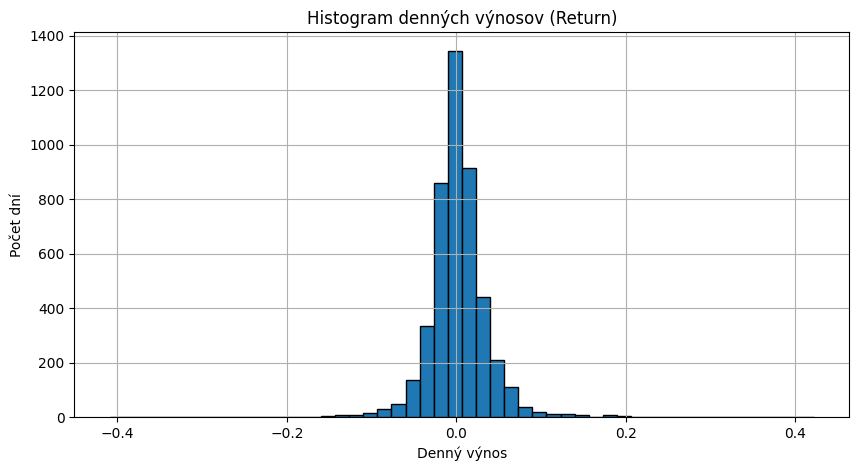

In [109]:

df["Return"] = df["Close"].pct_change()

plt.figure(figsize=(10,5))
plt.hist(df["Return"].dropna(), bins=50, edgecolor="black")
plt.title("Histogram denných výnosov (Return)")
plt.xlabel("Denný výnos")
plt.ylabel("Počet dní")
plt.grid(True)
plt.show()


Väčšina denných výnosov je sústredená blízko 0, čo je typické pre akciové trhy. Rozdelenie má dlhé chvosty – občasné extrémne kladné alebo záporné pohyby predstavujú obdobia vysokej volatility (earnings, správy, krízové udalosti). Tento atribút zachytáva dynamiku zmien ceny lepšie než samotné absolútne hodnoty Close.

Korelačná mapa

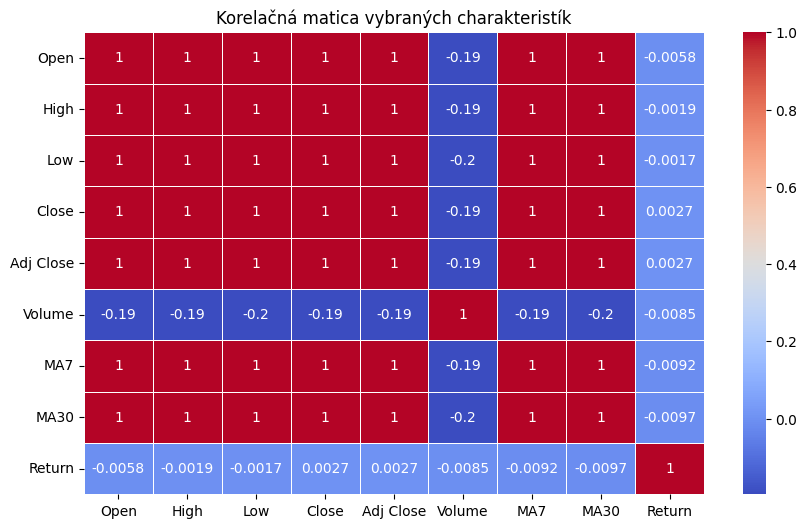

In [110]:
features_for_corr = ["Open", "High", "Low", "Close", "Adj Close", "Volume", "MA7", "MA30", "Return"]
plt.figure(figsize=(10,6))
sns.heatmap(df[features_for_corr].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Korelačná matica vybraných charakteristík")
plt.show()


Medzi cenovými atribútmi (Open, High, Low, Close, Adj Close) vidíme veľmi silnú koreláciu (blízko 1), čo znamená, že nesú podobnú informáciu a sú do veľkej miery redundantné. MA7 a MA30 sú tiež silno korelované s Close, ale zároveň filtrujú krátkodobý šum. Volume má nižšiu koreláciu s cenou, no môže pomôcť zachytiť dni so zvýšenou aktivitou. Return má len slabú koreláciu s úrovňou ceny, čo dáva zmysel – ide o zmenu, nie o samotnú úroveň.

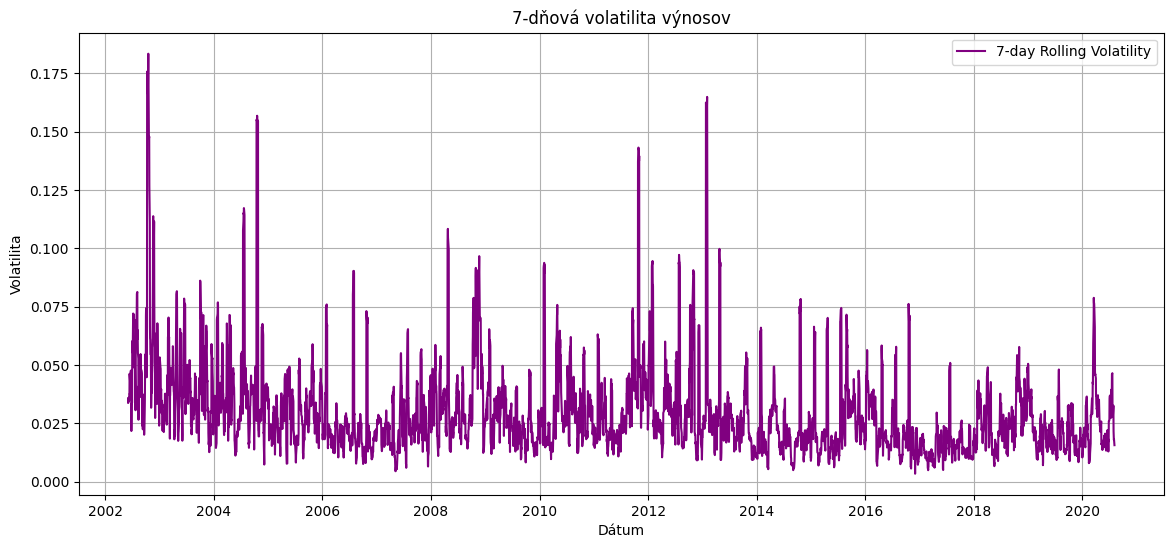

In [111]:
df["Volatility"] = df["Return"].rolling(window=7).std()

plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Volatility"], label="7-day Rolling Volatility", color="purple")
plt.title("7-dňová volatilita výnosov")
plt.xlabel("Dátum")
plt.ylabel("Volatilita")
plt.grid(True)
plt.legend()
plt.show()


Volatilita predstavuje mieru kolísania ceny v čase. Vyššie hodnoty volatility znamenajú, že denná zmena ceny bola nestabilná a akcia zaznamenala výraznejšie pohyby. Na grafe vidíme niekoľko výrazných špičiek (napr. okolo rokov 2004, 2008, 2013 a 2015), ktoré typicky súvisia s earnings správami, trhovými šokmi alebo významnými udalosťami v spoločnosti Netflix.

### 4.1(B)	Zdôvodnenie výberu ML/DL metód vzhľadom na vybraný dataset pre 4.2


Kedže v tejto úlohe pracujeme s datasetom Netflix 10+ Year Stock Data, ktorý obsahuje dlhodobý časový rad denných cien akcií, je teda vhodné na základe predošlej analýzy použiť také metódy ktoré dokážu pracovať s časovými radmi alebo zachytiť nelineárne spracovanie dát

**Voľba LM metód**

**Linear regresion**
Lineárna regresia slúži ako základný model. Je rýchla a poskytuje referenčnú hodnotu, voči ktorej môžeme porovnať výkon zložitejších modelov. Napriek tomu, že ceny akcií majú nelineárny vývoj, baseline je dôležitá pre objektívne porovnanie.

**Random Forest Regressor**
Random Forest je vhodný pre finančné dáta, pretože dokáže zachytávať nelineárne vzťahy, je robustný voči outlierom a nevyžaduje normalizáciu.Takisto dobre pracuje s viacerými vstupnými charakteristikami, ktoré môžu byť navzájom korelované (napr. Open, High, Low, Close).

**Gradient Boosting / XGBoost**
Boosting modely patria medzi najúčinnejšie metódy pre tieto dáta. vedia sa naučiť aj zložitejšie vzory, ktoré jednoduchšie modely nemusia vidieť. Veľmi dobre pracujú s trendom aj s volatilitou. Výhodou sú dobré vysledky aj pri menšich datasetoch čo sa nám akurát hodi


## 4.2 Modeling evaluation

### 4.2(A)	Modeluje Vami tie vybrané charakteristiky pomocou vhodných ML/DL metód. Výsledok modelovania je najlepší model.

#### Príprava dát na modelovanie

- Máme časový rad akcií teda ako postupovali ceny akcií netflixu. Budeme teda predikovať nasledujúcu zatváraciu cenu. 
- Vyberieme vstupné charakteristiky. Použijeme to, čo sme analyzovali
- Odstránime neplatné riadky
- Rozdelíme dáta na train a test. Rozdelili sme dáta v pomere 80/20
- Na koniec sme rozdelili X a y

In [112]:
df["Target"] = df["Close"].pct_change().shift(-1)

#### Vybrané charakteristiky

Použijeme tie features, ktoré sme analyzovali

In [113]:
# Výber relevantných charakteristík pre modelovanie
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "MA7",
    "MA30",
    "Return",
    "Volatility"
]

# Vytvorenie nového DataFrame pre modelovanie
df_model = df[features + ["Target"]].dropna().copy()

# Štatistické zhrnutie cieľovej premennej
df_model["Target"].describe()

# Rozdelenie dát na trénovaciu a testovaciu množinu (80% trénovacia, 20% testovacia)
split_index = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_index]
test_df  = df_model.iloc[split_index:]

# Príprava vstupných a výstupných premenných
X_train = train_df[features]
y_train = train_df["Target"]

X_test = test_df[features]
y_test = test_df["Target"]

# Tvar dát
print(y_train.min(), y_train.max())
print(y_test.min(), y_test.max())

-0.4090646586345381 0.4222350932916399
-0.11138862128059313 0.13543605075020504


#### Model 1 - Linear Regression

Lineárna regresia bola zvolená ako baseline model. Slúži ako referenčný bod, voči ktorému budeme porovnávať výkon zložitejších nelineárnych modelov. Hoci finančné časové rady vykazujú nelineárne správanie, baseline model je dôležitý pre objektívne vyhodnotenie prínosu komplexnejších metód.

Ako prvý krok musíme dáta ale scalenuť pretože lineárna regresia je citlivá na mierky a bez scalingu by váhu nedávali zmysle.

In [114]:
# Normalizácia dát pomocou StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Tréning lineárnej regresie
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predikcia na testovacej množine
y_pred_lr = lr_model.predict(X_test_scaled)

In [115]:
# Vyhodnotenie modelu
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression (return) MAE:", mae_lr)
print("Linear Regression (return) RMSE:", rmse_lr)

Linear Regression (return) MAE: 0.017687703694122342
Linear Regression (return) RMSE: 0.02474723223014329


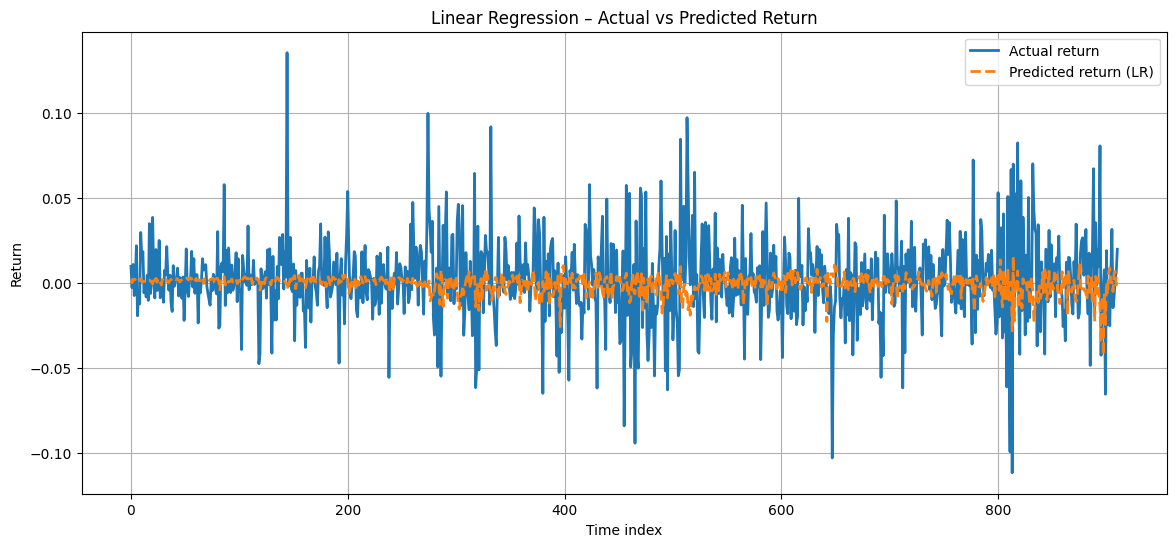

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(y_test.values, label="Actual return", linewidth=2)
plt.plot(y_pred_lr, label="Predicted return (LR)", linestyle="--", linewidth=2)

plt.title("Linear Regression – Actual vs Predicted Return")
plt.xlabel("Time index")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.show()

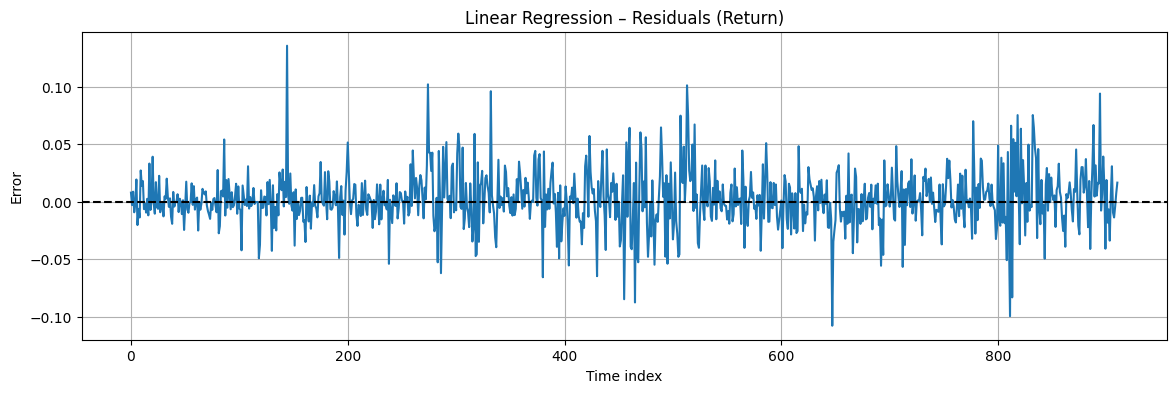

In [117]:
residuals_lr = y_test.values - y_pred_lr

plt.figure(figsize=(14,4))
plt.plot(residuals_lr)
plt.axhline(0, linestyle="--", color="black")

plt.title("Linear Regression – Residuals (Return)")
plt.xlabel("Time index")
plt.ylabel("Error")
plt.grid(True)
plt.show()

Lineárna regresia pri predikcii percentuálnej zmeny ceny dosahuje MAE = 1.8 % a RMSE = 2.5 %. Model má tendenciu vyhladzovať predikcie a približovať sa k nulovej hodnote, čo je dôsledok šumového charakteru denných výnosov a optimalizácie na minimalizáciu strednej kvadratickej chyby. Výsledky slúžia ako baseline pre porovnanie s nelineárnymi modelmi.

#### Model 2 - Random Forest

Random Forest Regressor bol zvolený ako nelineárny model schopný zachytiť komplexnejšie vzťahy medzi vstupnými charakteristikami. Na rozdiel od lineárnej regresie dokáže modelovať interakcie medzi premennými, je robustný voči outlierom a nevyžaduje škálovanie vstupných dát.

In [118]:
# Tréning Random Forest Regressora
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Trening modelu
rf_model.fit(X_train, y_train)

# Predikcia na testovacej množine
y_pred_rf = rf_model.predict(X_test)

print(y_train.min(), y_train.max())
print(y_test.min(), y_test.max())

-0.4090646586345381 0.4222350932916399
-0.11138862128059313 0.13543605075020504


In [119]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 0.01763710244009068
Random Forest RMSE: 0.024832135931978805


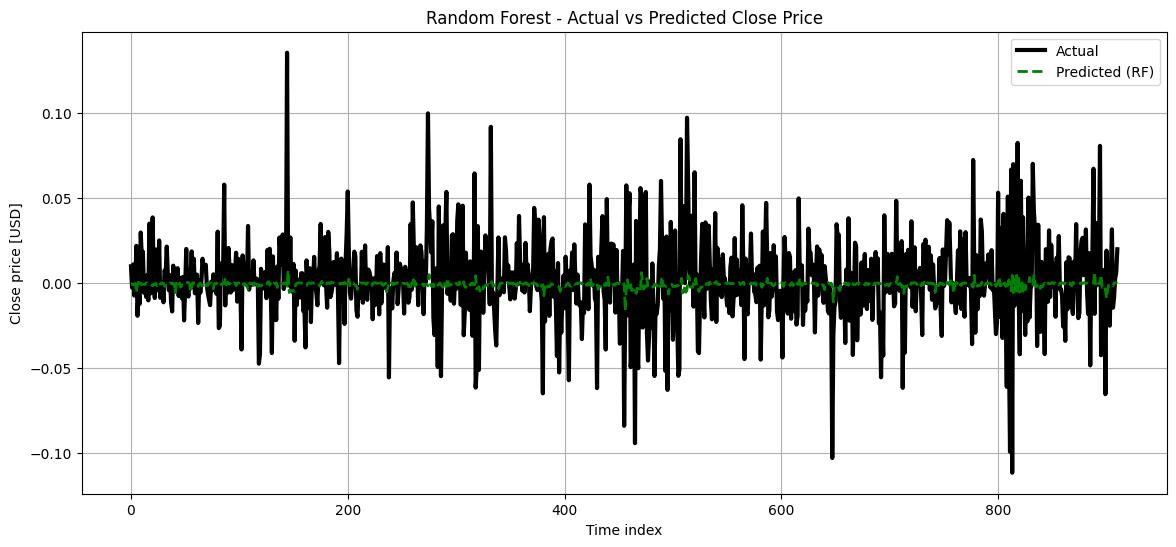

In [120]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values, label="Actual", linewidth=3, color="black")
plt.plot(y_pred_rf, label="Predicted (RF)", linestyle="--", linewidth=2, color="green")

plt.title("Random Forest - Actual vs Predicted Close Price")
plt.xlabel("Time index")
plt.ylabel("Close price [USD]")
plt.legend()
plt.grid(True)
plt.show()

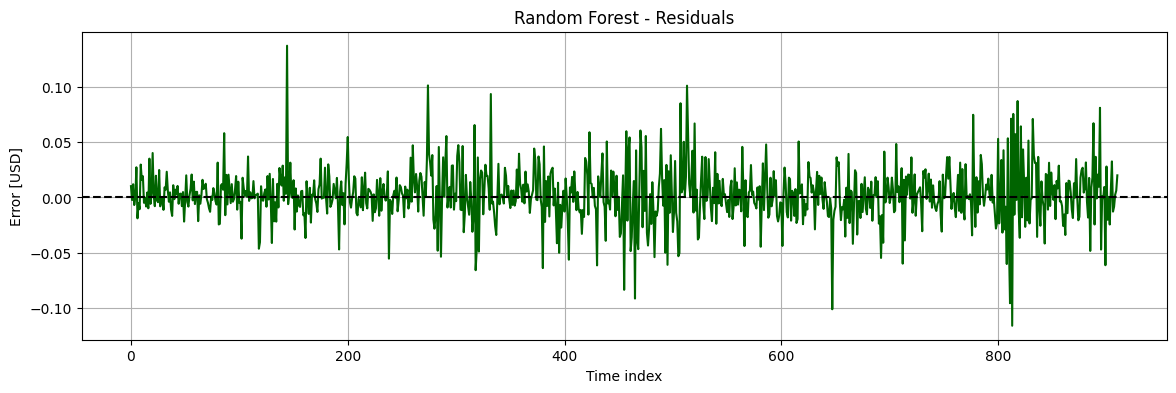

In [121]:
residuals_rf = y_test.values - y_pred_rf

plt.figure(figsize=(14,4))
plt.plot(residuals_rf, color="darkgreen")
plt.axhline(0, linestyle="--", color="black")

plt.title("Random Forest - Residuals")
plt.xlabel("Time index")
plt.ylabel("Error [USD]")
plt.grid(True)
plt.show()

Random Forest Regressor dosiahol porovnateľné výsledky ako lineárna regresia pri predikcii percentuálnej zmeny ceny. Hoci model dokáže zachytiť nelineárne vzťahy medzi vstupnými charakteristikami, prínos oproti jednoduchšiemu lineárnemu modelu je minimálny, čo poukazuje na vysoký podiel šumu v denných výnosoch akcií.

#### Model 3 - Gradient Boosting

Gradient Boosting Regressor je nelineárny model založený na postupnom učení slabých stromov, kde každý ďalší strom koriguje chyby predchádzajúcich. Oproti Random Forest dokáže lepšie zachytiť jemné vzory v dátach, avšak je citlivejší na šum.

In [122]:
# Tréning Gradient Boosting Regressora
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

# Tréning modelu
gb_model.fit(X_train, y_train)

# Predikcia na testovacej množine
y_pred_gb = gb_model.predict(X_test)

In [123]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print("Gradient Boosting MAE:", mae_gb)
print("Gradient Boosting RMSE:", rmse_gb)

Gradient Boosting MAE: 0.017782929223892487
Gradient Boosting RMSE: 0.025022507922861856


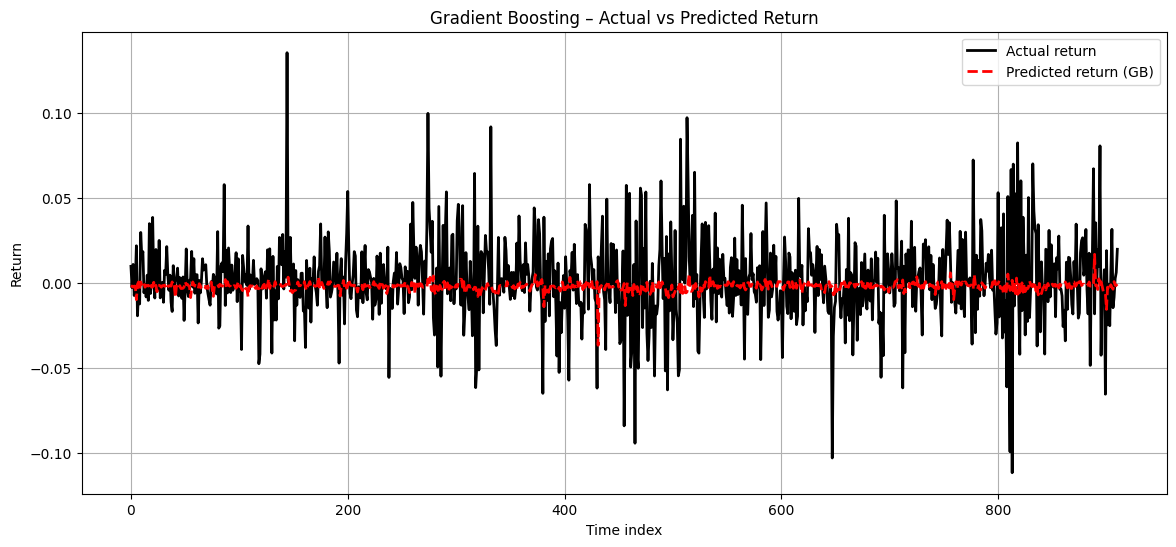

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(y_test.values, label="Actual return", linewidth=2, color="black")
plt.plot(y_pred_gb, label="Predicted return (GB)", linestyle="--", linewidth=2, color="red")

plt.title("Gradient Boosting - Actual vs Predicted Return")
plt.xlabel("Time index")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.show()

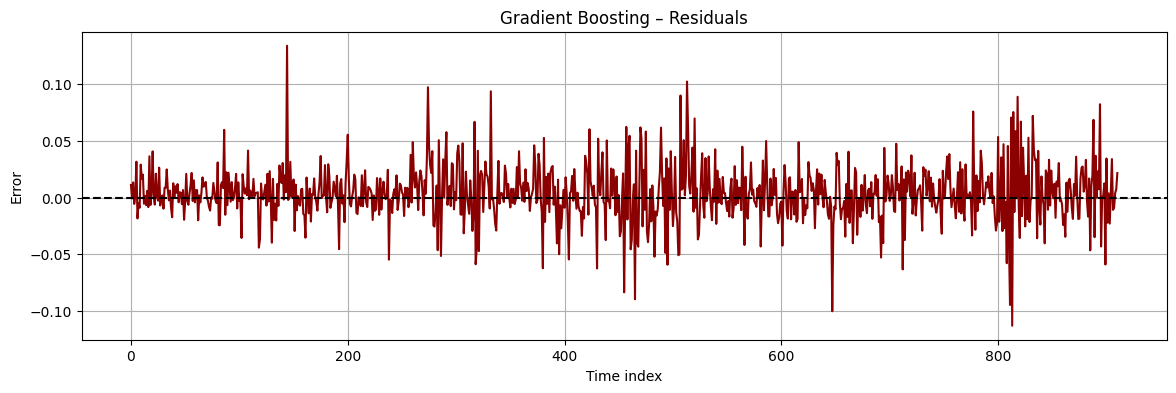

In [ ]:
residuals_gb = y_test.values - y_pred_gb

plt.figure(figsize=(14,4))
plt.plot(residuals_gb, color="darkred")
plt.axhline(0, linestyle="--", color="black")

plt.title("Gradient Boosting - Residuals")
plt.xlabel("Time index")
plt.ylabel("Error")
plt.grid(True)
plt.show()

Finálny test Gradient Boosting Regressora bol vykonaný na časovo oddelenej testovacej množine. Model dosiahol MAE = 1.78 % a RMSE = 2.50 %, čo je porovnateľné s výsledkami lineárnej regresie a Random Forestu. Dodatočný test smerovej presnosti potvrdil, že model zachytáva len veľmi slabý prediktívny signál. Výsledky naznačujú, že pri denných výnosoch akcií je potenciál zlepšenia pomocou komplexnejších modelov obmedzený vysokým podielom šumu.

### 4.2(B)	Zhodnotíte Váš prístup a získaný výsledok

V rámci riešenia úlohy bol zvolený systematický prístup k modelovaniu finančného časového radu. Pôvodne bola cieľovou premennou absolútna cena akcie, pri ktorej sa ukázalo, že nelineárne stromové modely nie sú vhodné z dôvodu neschopnosti extrapolovať dlhodobý trend. Tento problém bol vyriešený transformáciou cieľovej premennej na percentuálnu zmenu ceny (return), čím sa odstránil trend a zabezpečila porovnateľnosť trénovacích a testovacích dát.

Na takto definovanej úlohe boli porovnané tri modely – lineárna regresia, Random Forest a Gradient Boosting. Lineárna regresia slúžila ako baseline model, zatiaľ čo nelineárne modely boli použité na overenie, či dokážu lepšie zachytiť komplexnejšie vzory v dátach. Výsledky ukázali, že všetky tri modely dosahujú veľmi podobnú presnosť, pričom rozdiely v chybových metrikách (MAE, RMSE) boli minimálne.

Získané výsledky naznačujú, že pri predikcii denných výnosov akcií je prítomný vysoký podiel náhodnosti a dostupné vstupné charakteristiky obsahujú len obmedzený prediktívny signál. V tomto kontexte sa jednoduchší lineárny model ukázal ako rovnako efektívny ako komplexnejšie modely, pričom má výhodu nižšej komplexity a lepšej interpretovateľnosti. Zvolený prístup tak poskytuje realistické a metodicky správne zhodnotenie možností strojového učenia pri modelovaní finančných dát.